# K-Means Clustering — Complete Mathematical & Practical Guide

**Learning path:** Problem → Intuition → Mathematics → From Scratch → Visualization → Scikit-learn → Evaluation → Failure Cases → Applications

This notebook develops K-Means from its mathematical objective to a transparent NumPy implementation and a practical scikit-learn workflow.

## Learning Objectives

By completing this notebook, you will be able to:

- Explain what K-Means solves.
- Understand centroids, distance, assignment, and update steps.
- Understand and derive the WCSS objective.
- Implement K-Means from scratch with NumPy.
- Visualize centroid movement and convergence.
- Use `sklearn.cluster.KMeans`.
- Compare candidate values of `K`.
- Use the Elbow Method and Silhouette Score.
- Understand K-Means++ and feature scaling.
- Recognize important failure cases and limitations.

In [1]:
# Import the core libraries used throughout the notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make stochastic examples reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. What Is K-Means?

K-Means is an **unsupervised learning algorithm** that partitions observations into a predefined number of clusters.

It tries to make observations within the same cluster close to their cluster centroid, usually using Euclidean distance.

Unlike supervised learning, there is no target label that the algorithm learns to predict.

# 2. Intuition

K-Means repeatedly performs two operations:

1. **Assignment:** assign each observation to the nearest centroid.
2. **Update:** replace each centroid with the mean of the observations assigned to it.

The process repeats until the centroids or assignments stabilize.

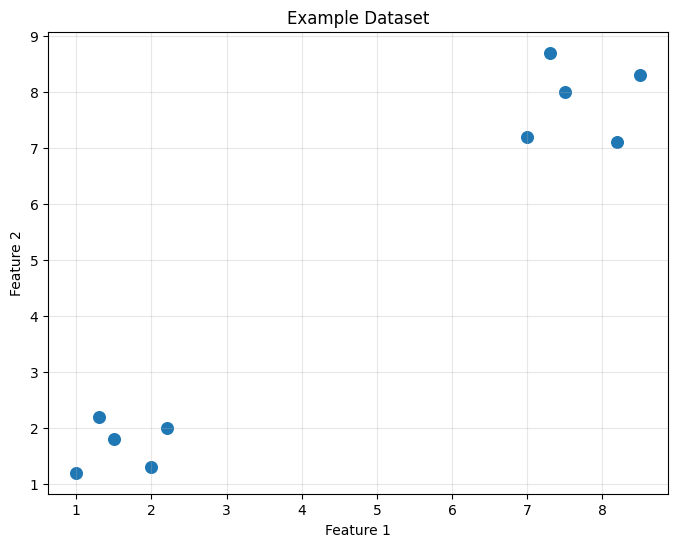

In [2]:
# Create a simple two-dimensional dataset so the algorithm can be visualized directly.
cluster_1 = np.array([[1.0, 1.2], [1.5, 1.8], [2.0, 1.3], [2.2, 2.0], [1.3, 2.2]])
cluster_2 = np.array([[7.0, 7.2], [7.5, 8.0], [8.2, 7.1], [8.5, 8.3], [7.3, 8.7]])
X_simple = np.vstack([cluster_1, cluster_2])

# Plot the observations before clustering.
plt.figure(figsize=(8, 6))
plt.scatter(X_simple[:, 0], X_simple[:, 1], s=70)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Example Dataset")
plt.grid(alpha=0.3)
plt.show()

# 3. Euclidean Distance

**Euclidean distance** measures the straight-line distance between two observations in a \(d\)-dimensional feature space.

For two observations \(x\) and \(y\):

$$
d(x,y)=\sqrt{\sum_{j=1}^{d}(x_j-y_j)^2}
$$

In **K-Means**, the objective function uses the **squared Euclidean distance**:

$$
d^2(x,y)=\sum_{j=1}^{d}(x_j-y_j)^2
$$

Using the squared distance avoids the square root and makes the **arithmetic mean** the optimal centroid for each cluster.

Therefore, K-Means assigns observations to the nearest centroid and updates each centroid using the mean of its assigned observations.

In [3]:
# Define Euclidean distance between two feature vectors.
def euclidean_distance(x, y):
    # Calculate the square root of the sum of squared feature differences.
    return np.sqrt(np.sum((x - y) ** 2))

# Test the distance function.
a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])
print(f"Euclidean distance: {euclidean_distance(a, b):.4f}")

Euclidean distance: 5.0000


# 4. Centroids

For a cluster containing $$(n)$$ observations:

$$
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

For multidimensional observations, the mean is calculated independently for each feature.

In [4]:
# Calculate the centroid of the first example cluster.
centroid_1 = cluster_1.mean(axis=0)
print("Cluster 1 centroid:", centroid_1)

Cluster 1 centroid: [1.6 1.7]


# 5. Why Is the Mean Used?

K-Means uses the **arithmetic mean** as the cluster centroid because the mean minimizes the sum of squared distances.

For a set of observations \(x_1, x_2, \ldots, x_n\), define the objective function:

$$
J(\mu)=\sum_{i=1}^{n}\|x_i-\mu\|^2
$$

To find the value of \(\mu\) that minimizes \(J(\mu)\), we take the derivative with respect to \(\mu\):

$$
\frac{\partial J}{\partial\mu}
=
-2\sum_{i=1}^{n}(x_i-\mu)
$$

Set the derivative equal to zero:

$$
-2\sum_{i=1}^{n}(x_i-\mu)=0
$$

Expanding the sum gives:

$$
\sum_{i=1}^{n}x_i-n\mu=0
$$

Solving for \(\mu\):

$$
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

Therefore, the optimal centroid is the **arithmetic mean** of the observations:

$$
\boxed{\mu=\frac{1}{n}\sum_{i=1}^{n}x_i}
$$

This is why K-Means updates each cluster centroid using the mean of the observations assigned to that cluster.

# 6. K-Means Objective Function

The **K-Means objective function** measures the total squared distance between each observation and the centroid of its assigned cluster.

The complete objective is:

$$
J=
\sum_{k=1}^{K}
\sum_{x_i\in C_k}
\|x_i-\mu_k\|^2
$$

where:

- \(K\) is the number of clusters.
- \(C_k\) is cluster \(k\).
- \(\mu_k\) is the centroid of cluster \(k\).
- \(x_i\) is an observation assigned to cluster \(k\).

This quantity is called the **Within-Cluster Sum of Squares (WCSS)**.

In **scikit-learn**, the same quantity is reported as **inertia**.

K-Means aims to find cluster assignments and centroids that **minimize the objective function**:

$$
\min_{\{C_k\},\{\mu_k\}} J
$$

A lower WCSS generally indicates that observations are closer to their assigned centroids.

# 7. The K-Means Algorithm

K-Means alternates between **assigning observations to clusters** and **updating the cluster centroids**.

The algorithm follows these steps:

1. **Initialize** \(K\) centroids.
2. **Assign** each observation to the nearest centroid.
3. **Update** each centroid using the mean of its assigned observations.
4. **Repeat** the assignment and update steps until convergence or the maximum number of iterations is reached.

The overall process can be summarized as:

$$
\boxed{
\text{Initialize}
\rightarrow
\text{Assign}
\rightarrow
\text{Update}
\rightarrow
\text{Repeat}
}
$$

At each iteration, K-Means attempts to reduce the **within-cluster sum of squares (WCSS)**.

In [5]:
# Demonstrate one assignment-update cycle.
initial_centroids = np.array([[2.0, 2.0], [7.5, 7.5]])

# Calculate squared distances from every observation to every centroid.
distances = np.sum(
    (X_simple[:, None, :] - initial_centroids[None, :, :]) ** 2,
    axis=2
)

# Assign each observation to the nearest centroid.
labels = np.argmin(distances, axis=1)

# Recalculate centroids using the mean of each assigned cluster.
updated_centroids = np.array([
    X_simple[labels == k].mean(axis=0) for k in range(2)
])

print("Initial centroids:")
print(initial_centroids)
print("\nUpdated centroids:")
print(updated_centroids)

Initial centroids:
[[2.  2. ]
 [7.5 7.5]]

Updated centroids:
[[1.6  1.7 ]
 [7.7  7.86]]


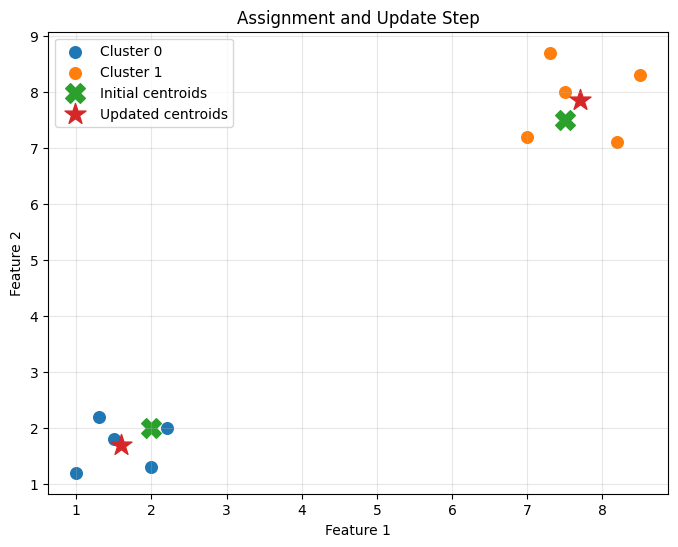

In [6]:
# Visualize the assignment and centroid update.
plt.figure(figsize=(8, 6))

for k in range(2):
    # Plot observations assigned to the current cluster.
    points = X_simple[labels == k]
    plt.scatter(points[:, 0], points[:, 1], s=70, label=f"Cluster {k}")

# Plot both the starting and updated centroid positions.
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1],
            marker="X", s=200, label="Initial centroids")
plt.scatter(updated_centroids[:, 0], updated_centroids[:, 1],
            marker="*", s=250, label="Updated centroids")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Assignment and Update Step")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. K-Means From Scratch

The implementation below contains:

- centroid initialization,
- nearest-centroid assignment,
- centroid updates,
- WCSS calculation,
- convergence checking,
- `fit`,
- `predict`,
- `fit_predict`.

It is intentionally written for transparency and learning rather than production optimization.

In [7]:
class KMeansScratch:
    """Educational K-Means implementation using NumPy."""

    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=None):
        # Store model parameters.
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # These attributes are learned during fitting.
        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.inertia_history_ = []

    def _initialize_centroids(self, X, rng):
        # Select distinct observations as the initial centroids.
        indices = rng.choice(X.shape[0], self.n_clusters, replace=False)
        return X[indices].copy()

    def _assign_clusters(self, X):
        # Calculate squared Euclidean distances to all centroids.
        distances = np.sum(
            (X[:, None, :] - self.centroids_[None, :, :]) ** 2,
            axis=2
        )
        # Assign each observation to its closest centroid.
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels, rng):
        # Allocate space for updated centroid coordinates.
        new_centroids = np.zeros_like(self.centroids_)

        for k in range(self.n_clusters):
            # Select observations assigned to cluster k.
            points = X[labels == k]

            if len(points) > 0:
                # The mean minimizes squared distance within the cluster.
                new_centroids[k] = points.mean(axis=0)
            else:
                # Reinitialize an empty cluster from a random observation.
                new_centroids[k] = X[rng.integers(0, len(X))]

        return new_centroids

    def _inertia(self, X, labels):
        # Calculate total within-cluster squared distance.
        total = 0.0

        for k in range(self.n_clusters):
            points = X[labels == k]
            if len(points) > 0:
                total += np.sum((points - self.centroids_[k]) ** 2)

        return total

    def fit(self, X):
        # Convert the input to a floating-point NumPy array.
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.random_state)

        # Initialize centroids.
        self.centroids_ = self._initialize_centroids(X, rng)
        self.inertia_history_ = []

        for iteration in range(self.max_iter):
            # Assignment step.
            labels = self._assign_clusters(X)

            # Update step.
            new_centroids = self._update_centroids(X, labels, rng)

            # Measure centroid movement before replacing the old centroids.
            shift = np.linalg.norm(new_centroids - self.centroids_)
            self.centroids_ = new_centroids

            # Recalculate assignments after the update.
            self.labels_ = self._assign_clusters(X)

            # Store the current objective value.
            self.inertia_history_.append(
                self._inertia(X, self.labels_)
            )

            self.n_iter_ = iteration + 1

            # Stop when centroid movement is sufficiently small.
            if shift <= self.tol:
                break

        self.inertia_ = self.inertia_history_[-1]
        return self

    def predict(self, X):
        # Predict the nearest cluster for new observations.
        if self.centroids_ is None:
            raise ValueError("Fit the model before prediction.")
        return self._assign_clusters(np.asarray(X, dtype=float))

    def fit_predict(self, X):
        # Fit the model and return the learned cluster assignments.
        self.fit(X)
        return self.labels_

In [8]:
# Generate a larger synthetic dataset for testing the scratch implementation.
from sklearn.datasets import make_blobs

X_blobs, _ = make_blobs(
    n_samples=450,
    centers=3,
    cluster_std=1.0,
    random_state=RANDOM_STATE
)

# Fit the educational implementation.
scratch = KMeansScratch(
    n_clusters=3,
    max_iter=100,
    tol=1e-4,
    random_state=RANDOM_STATE
)
labels_scratch = scratch.fit_predict(X_blobs)

print("Iterations:", scratch.n_iter_)
print("Final WCSS:", scratch.inertia_)
print("Centroids:")
print(scratch.centroids_)

Iterations: 2
Final WCSS: 861.244814124276
Centroids:
[[ 4.66665503  1.93198276]
 [-2.55001056  9.03069552]
 [-6.85396858 -6.76024817]]


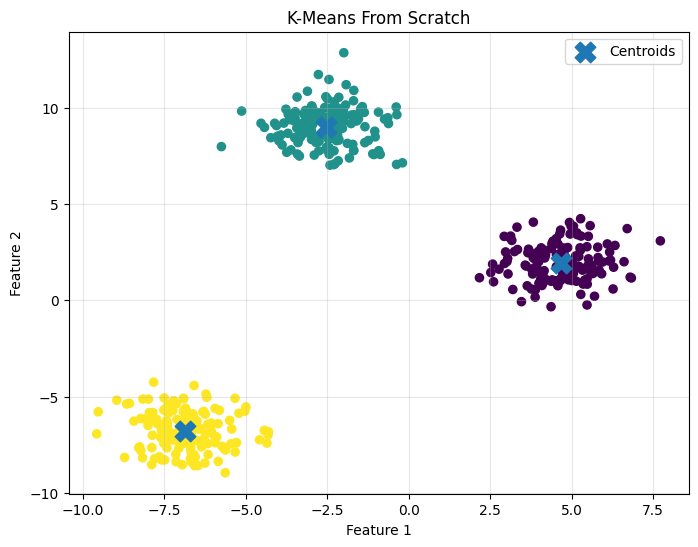

In [9]:
# Plot the clusters learned by the scratch implementation.
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_scratch, s=35)

plt.scatter(
    scratch.centroids_[:, 0],
    scratch.centroids_[:, 1],
    marker="X", s=220, label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means From Scratch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 9. Objective During Optimization

The WCSS should generally decrease as the algorithm improves its current solution.

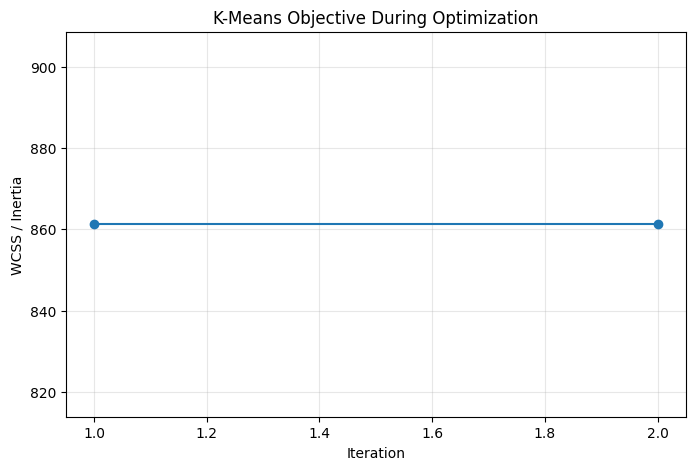

In [10]:
# Plot WCSS after each iteration of the scratch implementation.
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(scratch.inertia_history_) + 1),
    scratch.inertia_history_,
    marker="o"
)
plt.xlabel("Iteration")
plt.ylabel("WCSS / Inertia")
plt.title("K-Means Objective During Optimization")
plt.grid(alpha=0.3)
plt.show()

# 10. Visualizing Centroid Movement

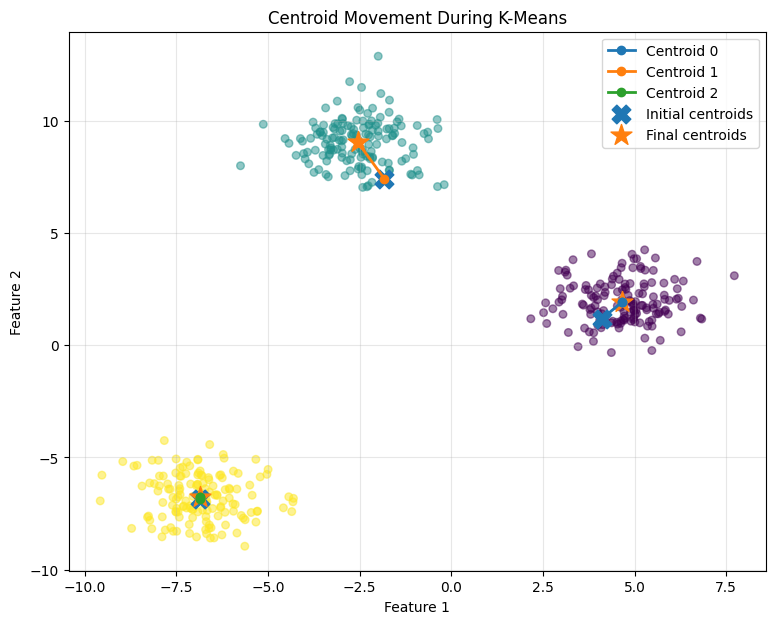

In [11]:
def kmeans_with_history(X, n_clusters=3, max_iter=20, random_state=42):
    # Create a reproducible random generator.
    rng = np.random.default_rng(random_state)

    # Initialize centroids from randomly selected observations.
    centroids = X[rng.choice(len(X), n_clusters, replace=False)].copy()
    history = [centroids.copy()]

    for _ in range(max_iter):
        # Assignment step.
        distances = np.sum(
            (X[:, None, :] - centroids[None, :, :]) ** 2,
            axis=2
        )
        labels = np.argmin(distances, axis=1)

        # Update step.
        new_centroids = np.array([
            X[labels == k].mean(axis=0)
            if np.any(labels == k) else centroids[k]
            for k in range(n_clusters)
        ])

        history.append(new_centroids.copy())

        # Stop when centroid locations stop changing.
        if np.allclose(new_centroids, centroids):
            break

        centroids = new_centroids

    return labels, centroids, history


labels_h, final_c, history = kmeans_with_history(
    X_blobs, n_clusters=3, random_state=RANDOM_STATE
)

# Plot centroid trajectories.
plt.figure(figsize=(9, 7))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_h, s=30, alpha=0.5)

for k in range(3):
    trajectory = np.array([step[k] for step in history])
    plt.plot(
        trajectory[:, 0], trajectory[:, 1],
        marker="o", linewidth=2, label=f"Centroid {k}"
    )

plt.scatter(history[0][:, 0], history[0][:, 1],
            marker="X", s=180, label="Initial centroids")
plt.scatter(history[-1][:, 0], history[-1][:, 1],
            marker="*", s=250, label="Final centroids")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Centroid Movement During K-Means")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 11. Scikit-learn Implementation

In [12]:
# Import the tested scikit-learn implementation.
from sklearn.cluster import KMeans

# Configure K-Means using K-Means++ initialization.
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=RANDOM_STATE
)

# Fit the model and obtain cluster assignments.
labels_sklearn = kmeans.fit_predict(X_blobs)

print("Iterations:", kmeans.n_iter_)
print("Inertia:", kmeans.inertia_)
print("Centroids:")
print(kmeans.cluster_centers_)

Iterations: 2
Inertia: 861.2448141242753
Centroids:
[[-2.55001056  9.03069552]
 [-6.85396858 -6.76024817]
 [ 4.66665503  1.93198276]]


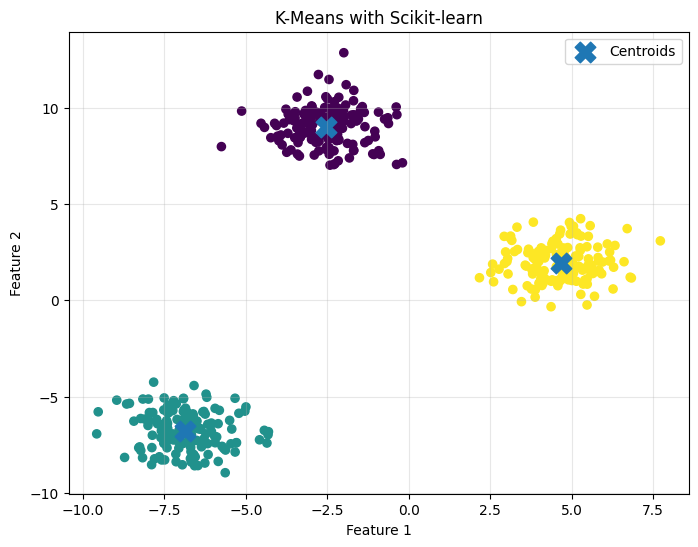

In [13]:
# Visualize the scikit-learn result.
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_sklearn, s=35)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X", s=220, label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means with Scikit-learn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 12. Important Parameters

- `n_clusters`: number of clusters \(K\).
- `init`: centroid initialization strategy.
- `n_init`: number of independent initializations.
- `max_iter`: maximum iterations per initialization.
- `tol`: convergence tolerance.
- `random_state`: reproducibility control.

# 13. Choosing K

K-Means requires \(K\), but the appropriate value is usually unknown.

Two common diagnostics are:

- **Elbow Method**
- **Silhouette Score**

These are evidence for model selection, not automatic proof of a "true" number of clusters.

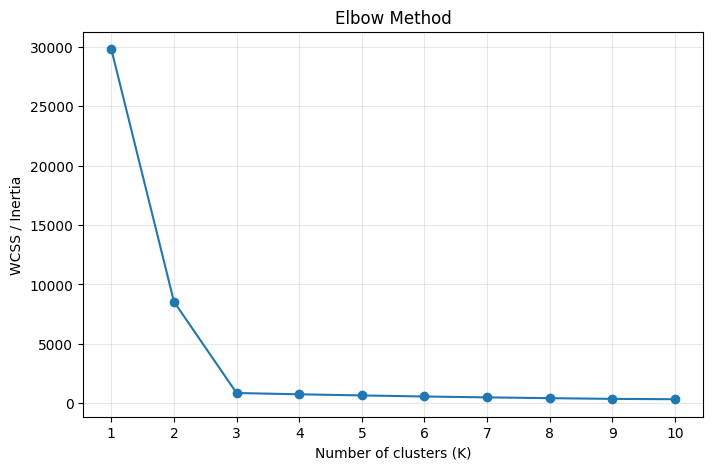

In [14]:
# Evaluate WCSS for candidate values of K.
k_values = range(1, 11)
inertias = []

for k in k_values:
    # Fit K-Means for the current candidate K.
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE
    )
    model.fit(X_blobs)
    inertias.append(model.inertia_)

# Plot the Elbow curve.
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

## 13.1 Silhouette Score

The **Silhouette Score** evaluates how well each observation fits within its assigned cluster compared with neighboring clusters.

For observation \(i\):

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

where:

- \(a(i)\) is the average distance from observation \(i\) to other observations in its **own cluster**.
- \(b(i)\) is the lowest average distance from observation \(i\) to observations in **another cluster**.

The Silhouette Score ranges from \(-1\) to \(1\):

- A value close to **1** indicates good cluster cohesion and separation.
- A value around **0** indicates overlapping or poorly separated clusters.
- A negative value may indicate that an observation is assigned to the wrong cluster.

Therefore, **higher average Silhouette Scores generally indicate better-defined clusters**.

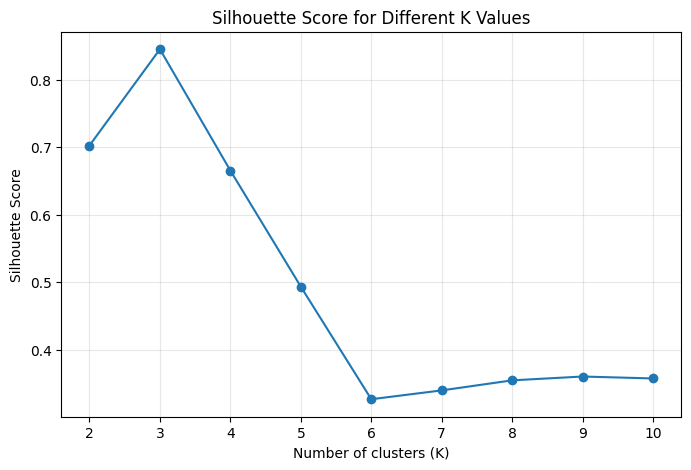

In [15]:
# Evaluate candidate values of K using the Silhouette Score.
from sklearn.metrics import silhouette_score

k_values_silhouette = range(2, 11)
scores = []

for k in k_values_silhouette:
    # Fit the model for the current K.
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_blobs)

    # Calculate the average Silhouette Score.
    scores.append(silhouette_score(X_blobs, labels))

# Plot the scores.
plt.figure(figsize=(8, 5))
plt.plot(k_values_silhouette, scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(k_values_silhouette))
plt.grid(alpha=0.3)
plt.show()

# 14. K-Means++

Random initialization can lead to different local solutions.

**K-Means++** selects initial centroids so that they tend to be spread across the feature space. It improves initialization but does not change the fundamental assignment/update algorithm.

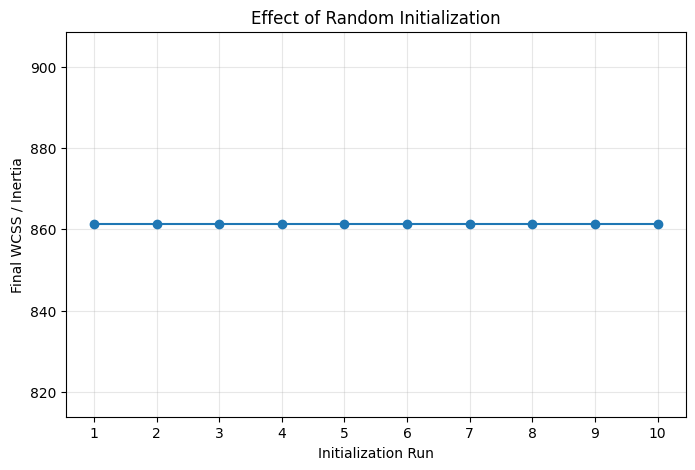

Best inertia: 861.2448141242753
Worst inertia: 861.2448141242753


In [16]:
# Show how different random initializations can produce different final objectives.
initialization_inertias = []

for seed in range(10):
    # Use one random initialization so the initialization effect is visible.
    model = KMeans(
        n_clusters=3,
        init="random",
        n_init=1,
        random_state=seed
    )
    model.fit(X_blobs)
    initialization_inertias.append(model.inertia_)

# Plot the resulting objective values.
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), initialization_inertias, marker="o")
plt.xlabel("Initialization Run")
plt.ylabel("Final WCSS / Inertia")
plt.title("Effect of Random Initialization")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

print("Best inertia:", min(initialization_inertias))
print("Worst inertia:", max(initialization_inertias))

# 15. Feature Scaling

K-Means is distance-based, so feature scale can strongly affect clustering.

A feature with values from 0 to 100000 can dominate a feature ranging from 0 to 1.

Standardization is often appropriate when features have substantially different scales, but the transformation should be justified by the data and scientific question.

In [17]:
# Create two features with very different numerical scales.
rng = np.random.default_rng(RANDOM_STATE)
X_scale = np.column_stack([
    rng.normal(0, 1, 300),
    rng.normal(0, 1000, 300)
])

# Fit K-Means before scaling.
unscaled = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
unscaled_labels = unscaled.fit_predict(X_scale)

# Standardize the features.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scale)

# Fit K-Means after scaling.
scaled = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
scaled_labels = scaled.fit_predict(X_scaled)

print("Unscaled inertia:", unscaled.inertia_)
print("Scaled inertia:", scaled.inertia_)

Unscaled inertia: 54190284.65574118
Scaled inertia: 265.5635590016494


# 16. Failure Cases and Limitations

K-Means can struggle with:

- Non-spherical or elongated clusters
- Different cluster sizes
- Different cluster densities
- Outliers
- An unsuitable value of \(K\)
- Unscaled features
- Poor initialization
- High-dimensional feature spaces where distance relationships become less informative

These are algorithmic assumptions and should be considered before interpreting results.

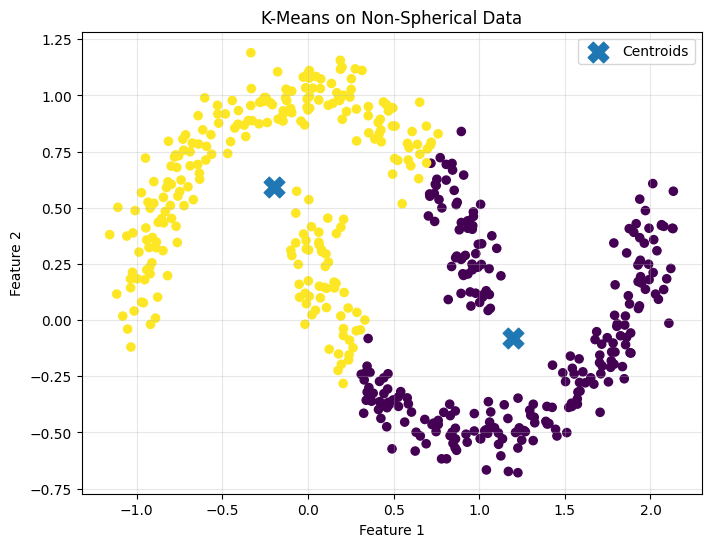

In [18]:
# Create a classic non-spherical two-moons dataset.
from sklearn.datasets import make_moons

X_moons, _ = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=RANDOM_STATE
)

# Apply K-Means to the curved structures.
moon_model = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=RANDOM_STATE
)
moon_labels = moon_model.fit_predict(X_moons)

# Visualize the resulting partition.
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=moon_labels, s=35)

plt.scatter(
    moon_model.cluster_centers_[:, 0],
    moon_model.cluster_centers_[:, 1],
    marker="X", s=220, label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means on Non-Spherical Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The two-moons example illustrates an important limitation: K-Means only considers distances to centroids. It does not understand that the observations form curved structures.

For density-based or more complex geometry, algorithms such as **DBSCAN** can be more appropriate.

# 17. K-Means vs. Classification

**Classification** is a **supervised learning** task because the target labels are known during training.

$$
X \rightarrow y
$$

where \(y\) represents the known target label.

In contrast, **K-Means** is an **unsupervised learning** algorithm. It discovers groups directly from the input features without using predefined labels.

$$
X \rightarrow \text{Cluster Assignments}
$$

Therefore, K-Means cluster IDs should **not automatically be interpreted as true biological, clinical, or semantic classes**.

For example, if K-Means produces clusters labeled `0`, `1`, and `2`, these numbers are simply identifiers assigned to the discovered clusters. They do not inherently represent specific disease subtypes, patient groups, or biological states.

To interpret clusters meaningfully, their characteristics must be analyzed using **external variables, domain knowledge, or downstream validation**.

# 18. Evaluation and Interpretation

Useful internal metrics include:

- WCSS / Inertia
- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

But numerical metrics alone are not sufficient.

Depending on the application, interpretation may also require:

- Cluster stability
- External validation
- Domain knowledge
- Statistical testing
- Biological or clinical validation
- Reproducibility across datasets

A visually appealing clustering result is not automatically a meaningful discovery.

# 19. Practical Workflow

```text
Load Data
    ↓
Inspect Features
    ↓
Handle Missing Values
    ↓
Select Relevant Features
    ↓
Scale Features When Appropriate
    ↓
Explore Data
    ↓
Test Candidate K Values
    ↓
Fit K-Means
    ↓
Evaluate
    ↓
Check Stability
    ↓
Interpret
    ↓
Validate With Domain Knowledge
```

# 20. Applications

K-Means can be used for:

- Customer segmentation
- Biological data exploration
- Patient stratification
- Image and embedding analysis
- Exploratory data analysis
- Pattern discovery

The meaning of a cluster always depends on the features used to construct it.

# 21. Key Takeaways

1. K-Means is an **unsupervised clustering algorithm**.
2. It requires a chosen number of clusters \(K\).
3. Each cluster is represented by a centroid.
4. Assignment maps observations to the nearest centroid.
5. Update replaces each centroid with the mean of its assigned observations.
6. K-Means minimizes within-cluster squared distances.
7. The arithmetic mean is optimal for the squared-distance objective.
8. Initialization can affect the final solution.
9. K-Means++ improves initialization.
10. Feature scaling is often important.
11. Elbow and Silhouette are useful diagnostics for \(K\).
12. K-Means can fail on non-spherical, differently sized, differently dense, or outlier-heavy data.
13. A cluster is not automatically a meaningful real-world category.
14. Scientific interpretation requires validation beyond the clustering algorithm.

# 22. References

- MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations.*
- Lloyd, S. (1982). *Least Squares Quantization in PCM.*
- Arthur, D., & Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding.*
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.*
- Scikit-learn documentation for K-Means and clustering metrics.